In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [4]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


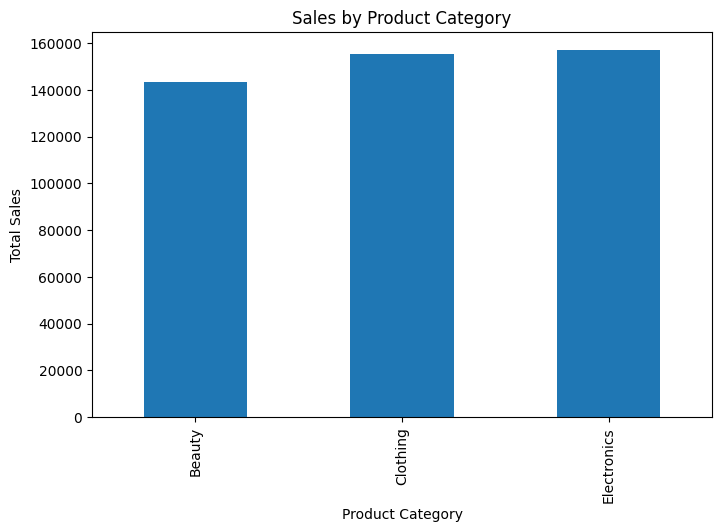

In [7]:
plt.figure(figsize=(8,5))

category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales.plot(kind='bar')

plt.title('Sales by Product Category')
plt.ylabel('Total Sales')

plt.savefig("sales_by_category.png", bbox_inches='tight')

plt.show()

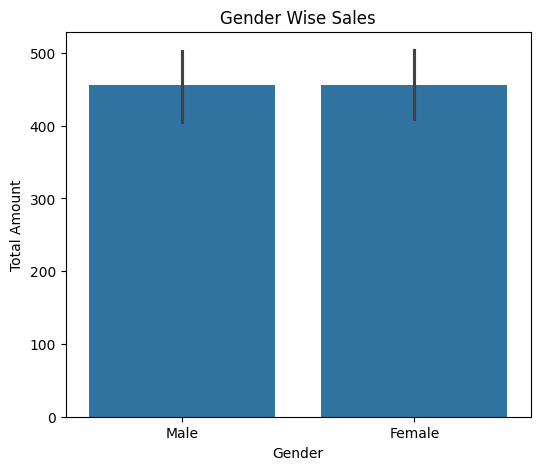

In [8]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x='Gender',
    y='Total Amount'
)

plt.title('Gender Wise Sales')

plt.savefig("gender_wise_sales.png", bbox_inches='tight')

plt.show()

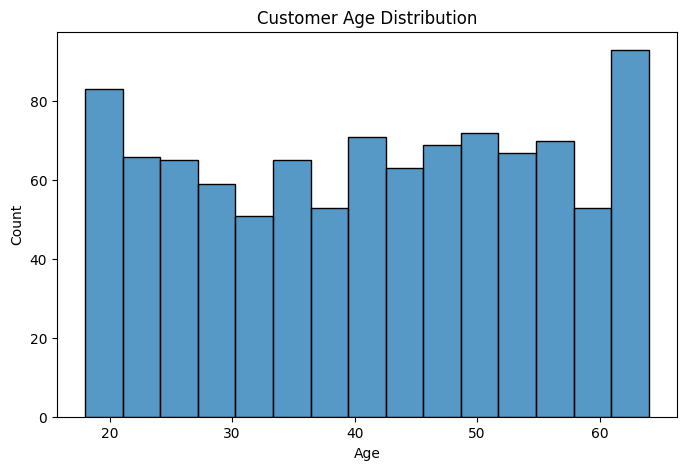

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15)

plt.title('Customer Age Distribution')

plt.savefig("age_distribution.png", bbox_inches='tight')

plt.show()

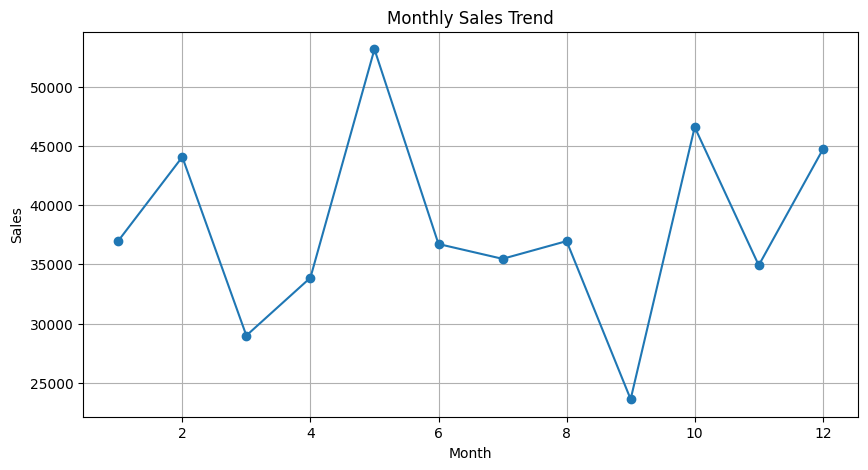

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')

plt.ylabel('Sales')

plt.grid(True)

plt.savefig("monthly_sales_trend.png",
            bbox_inches='tight')

plt.show()

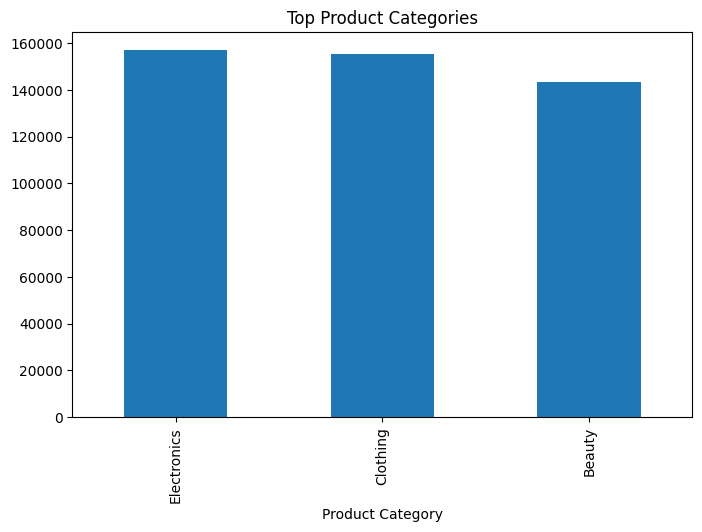

In [11]:
top_products = df.groupby(
    'Product Category'
)['Total Amount'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))

top_products.plot(kind='bar')

plt.title('Top Product Categories')

plt.savefig("top_product_categories.png",
            bbox_inches='tight')

plt.show()

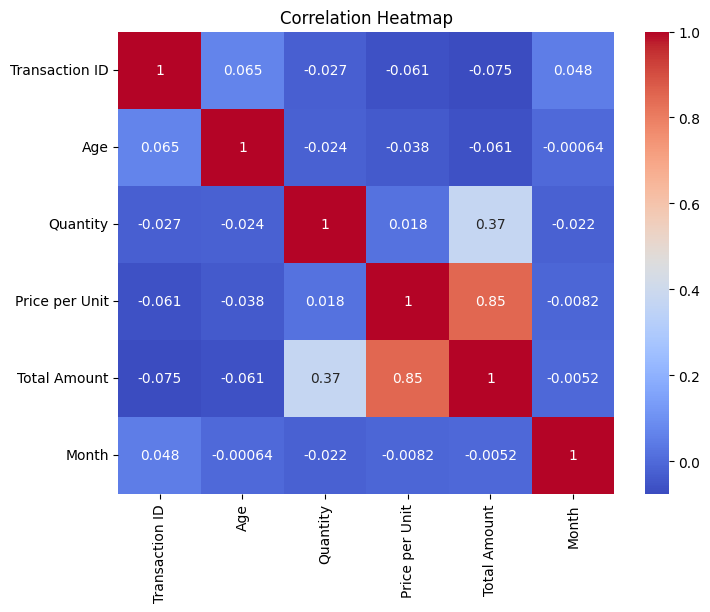

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig("correlation_heatmap.png",
            bbox_inches='tight')

plt.show()

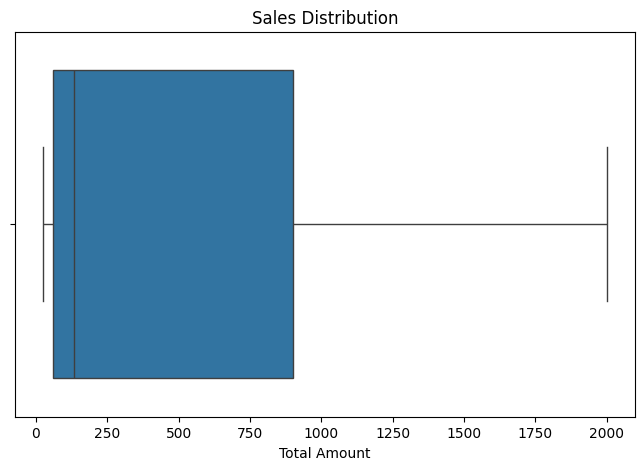

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Total Amount']
)

plt.title('Sales Distribution')

plt.savefig("sales_distribution.png",
            bbox_inches='tight')

plt.show()